# Gender Classification — ViT-B/16 Two-Phase Fine-Tuning

**Dataset:** UTKFace (via kagglehub)  
**Architecture:** `vit_base_patch16_224` (ImageNet-21k pretrained)  

| Phase | Backbone | Head | LR |
|---|---|---|---|
| 1 | Frozen | Trainable | `1e-3` |
| 2 | Last 4 blocks unfrozen | Trainable | `1e-5` / `1e-4` |

---

## 1. Environment Setup

In [1]:
!pip install -q timm==0.9.16 torchinfo matplotlib seaborn scikit-learn kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.6 MB/s eta 0:00:00


In [2]:
import os, sys, math, random, shutil
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as T

import timm
from timm.loss import LabelSmoothingCrossEntropy

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, \
    confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import train_test_split

import cv2
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"timm:    {timm.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device:  {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
timm:    0.9.16
CUDA:    True
Device:  Tesla T4


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset — UTKFace

UTKFace contains ~23k face images labelled by age, gender, and race.  
Filename format: `[age]_[gender]_[race]_[date&time].jpg`  
Gender: `0` = male, `1` = female

In [4]:
DATA_DIR = Path("data/utkface")
extracted_dir = DATA_DIR / "UTKFace"

if extracted_dir.exists() and len(list(extracted_dir.iterdir())) > 0:
    print(f"Dataset already exists at {extracted_dir}")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    import kagglehub
    print("Downloading UTKFace via kagglehub...")
    path = kagglehub.dataset_download("jangedoo/utkface-new")
    download_path = Path(path)
    for f in download_path.iterdir():
        if f.is_dir():
            shutil.copytree(f, extracted_dir, dirs_exist_ok=True)
        elif f.suffix.lower() in (".jpg", ".png"):
            extracted_dir.mkdir(exist_ok=True)
            shutil.copy2(f, extracted_dir / f.name)
    print(f"Extracted to {extracted_dir}")

image_paths = list(extracted_dir.glob("*.jpg")) + list(extracted_dir.glob("*.png"))
print(f"Total images: {len(image_paths)}")

Using Colab cache for faster access to the 'utkface-new' dataset.
Extracted to data/utkface/UTKFace
Total images: 23709


In [5]:
def parse_utkface_filename(filename: str):
    stem = Path(filename).stem
    parts = stem.split('_')
    if len(parts) < 3:
        return None
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        return {"age": age, "gender": gender, "race": race}
    except (ValueError, IndexError):
        return None

records = []
for p in image_paths:
    parsed = parse_utkface_filename(p.name)
    if parsed is not None:
        records.append({"path": str(p), **parsed})

df = pd.DataFrame(records)
print(f"Parsed {len(df)} / {len(image_paths)} images successfully")

Parsed 23705 / 23709 images successfully


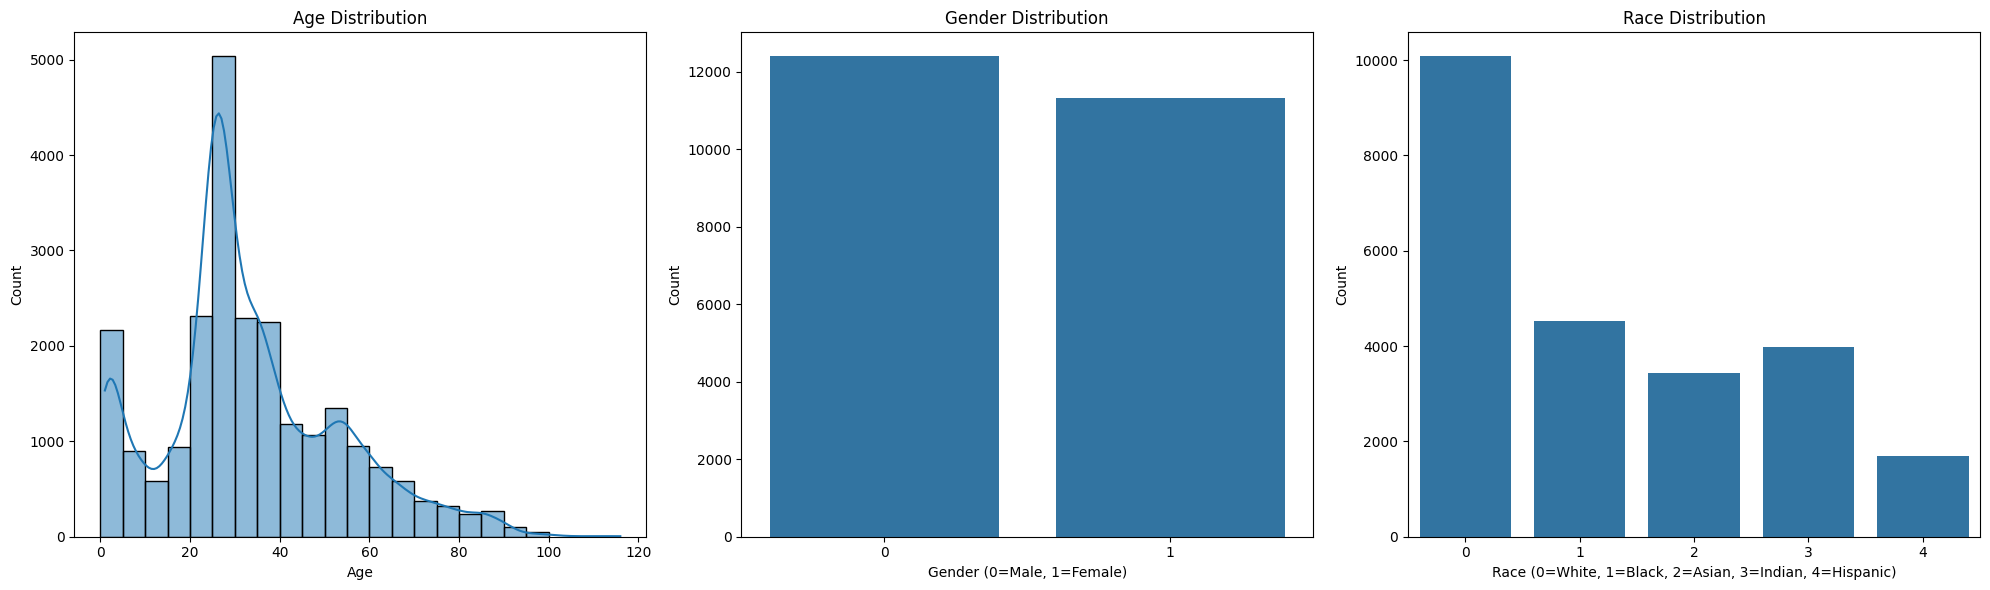

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(df['age'], bins=range(0, 101, 5), kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.countplot(x='gender', data=df, ax=axes[1])
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender (0=Male, 1=Female)')
axes[1].set_ylabel('Count')

sns.countplot(x='race', data=df, ax=axes[2])
axes[2].set_title('Race Distribution')
axes[2].set_xlabel('Race (0=White, 1=Black, 2=Asian, 3=Indian, 4=Hispanic)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

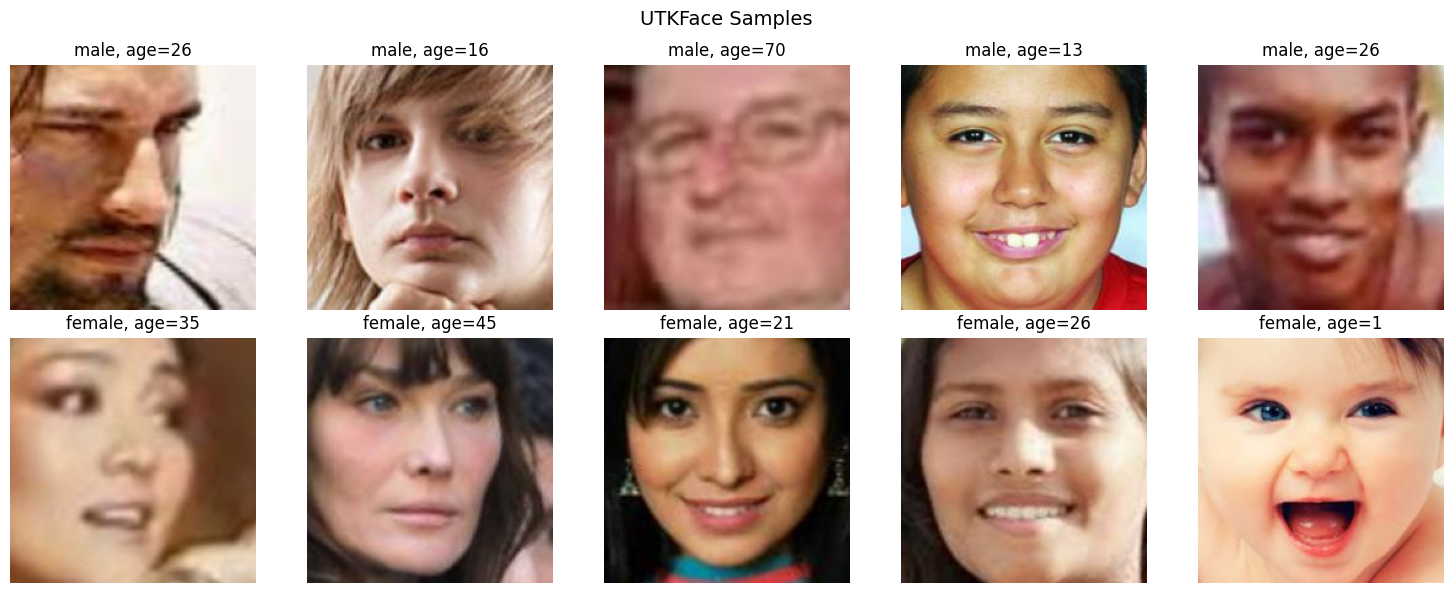

gender
male      12391
female    11314
Name: count, dtype: int64
Age range: 1 - 116


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
samples = df.groupby('gender').sample(5, random_state=SEED)
for i, (_, row) in enumerate(samples.iterrows()):
    ax = axes[i // 5, i % 5]
    img = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{'male' if row['gender']==0 else 'female'}, age={row['age']}")
    ax.axis('off')
plt.suptitle("UTKFace Samples", fontsize=14)
plt.tight_layout()
plt.show()

print(df['gender'].map({0:'male',1:'female'}).value_counts())
print(f"Age range: {df['age'].min()} - {df['age'].max()}")

## 3. Data Loaders

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfm = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['gender'], dtype=torch.long)

In [8]:
BATCH_SIZE = 64
NW = 0  # 0 avoids multiprocessing cleanup warnings in notebook environments

train_idx, temp_idx = train_test_split(
    np.arange(len(df)), test_size=0.3,
    stratify=df['gender'], random_state=SEED)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5,
    stratify=df.iloc[temp_idx]['gender'], random_state=SEED)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

train_loader = DataLoader(UTKFaceDataset(train_df, train_tfm),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NW, pin_memory=True)
val_loader   = DataLoader(UTKFaceDataset(val_df, eval_tfm),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)
test_loader  = DataLoader(UTKFaceDataset(test_df, eval_tfm),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 16593 | Val: 3556 | Test: 3556


## 4. Model Definition

`vit_base_patch16_224` from `timm` with a 2-class MLP head.  
Includes `freeze_backbone()` and `unfreeze_last_n_blocks()` methods for the two-phase protocol.

In [9]:
class GenderClassifier(nn.Module):
    BACKBONE_NAME = "vit_base_patch16_224"
    EMBED_DIM = 768
    HIDDEN_DIM = 256
    NUM_CLASSES = 2
    DROPOUT = 0.3

    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            self.BACKBONE_NAME, pretrained=True,
            num_classes=0, global_pool='token')
        self.head = nn.Sequential(
            nn.LayerNorm(self.EMBED_DIM),
            nn.Linear(self.EMBED_DIM, self.HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(p=self.DROPOUT),
            nn.Linear(self.HIDDEN_DIM, self.NUM_CLASSES))
        self._init_head_weights()

    def _init_head_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_n_blocks(self, n: int = 4):
        for block in list(self.backbone.blocks)[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.backbone.norm.parameters():
            p.requires_grad = True

    @property
    def num_trainable(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @property
    def num_total(self):
        return sum(p.numel() for p in self.parameters())

---
# Phase 1 — Head-Only Fine-Tuning

Backbone frozen, only the 2-layer MLP head is trained.

In [10]:
model = GenderClassifier()
model.freeze_backbone()
model = model.to(DEVICE)

print(f"Total params:     {model.num_total:,}")
print(f"Trainable params: {model.num_trainable:,} ({100*model.num_trainable/model.num_total:.2f}%)")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total params:     85,997,570
Trainable params: 198,914 (0.23%)


In [11]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                        Output Shape              Param #
GenderClassifier                              [1, 2]                    --
├─VisionTransformer: 1-1                      [1, 768]                  152,064
│    └─PatchEmbed: 2-1                        [1, 196, 768]             --
│    │    └─Conv2d: 3-1                       [1, 768, 14, 14]          (590,592)
│    │    └─Identity: 3-2                     [1, 196, 768]             --
│    └─Dropout: 2-2                           [1, 197, 768]             --
│    └─Identity: 2-3                          [1, 197, 768]             --
│    └─Identity: 2-4                          [1, 197, 768]             --
│    └─Sequential: 2-5                        [1, 197, 768]             --
│    │    └─Block: 3-3                        [1, 197, 768]             (7,087,872)
│    │    └─Block: 3-4                        [1, 197, 768]             (7,087,872)
│    │    └─Block: 3-5                        [1, 197, 768]      

### Phase 1 — Hyperparameters

In [13]:
P1_EPOCHS = 15
P1_LR = 1e-3
P1_WD = 1e-4
P1_PATIENCE = 5
P1_DELTA = 0.001

criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.head.parameters(), lr=P1_LR, weight_decay=P1_WD)
scheduler = CosineAnnealingLR(optimizer, T_max=P1_EPOCHS, eta_min=1e-6)

print(f"Phase 1: AdamW head-only | lr={P1_LR} | wd={P1_WD} | epochs={P1_EPOCHS} | patience={P1_PATIENCE}")

Phase 1: AdamW head-only | lr=0.001 | wd=0.0001 | epochs=15 | patience=5


### Phase 1 — Training Loop

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, n = 0.0, 0
    preds, labels = [], []
    for imgs, lbls in tqdm(loader, desc="Train", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        bs = imgs.size(0)
        loss_sum += loss.item() * bs
        n += bs
        preds.extend(logits.argmax(dim=-1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())
    return loss_sum / n, accuracy_score(labels, preds)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, n = 0.0, 0
    preds, labels, probs = [], [], []
    for imgs, lbls in tqdm(loader, desc="Eval", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = model(imgs)
        loss_sum += criterion(logits, lbls).item() * imgs.size(0)
        n += imgs.size(0)
        p = F.softmax(logits, dim=-1)
        preds.extend(logits.argmax(dim=-1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())
        probs.extend(p.cpu().numpy())
    return (loss_sum / n, accuracy_score(labels, preds),
            np.array(labels), np.array(preds), np.array(probs))

In [15]:
best_val_loss = float('inf')
best_val_acc = 0.0
stale_epochs = 0
p1_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8} |{'LR':>10} | Early")
print("-" * 80)

for epoch in range(1, P1_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    p1_history['train_loss'].append(tr_loss)
    p1_history['train_acc'].append(tr_acc)
    p1_history['val_loss'].append(vl_loss)
    p1_history['val_acc'].append(vl_acc)

    status = ''
    if vl_loss < best_val_loss - P1_DELTA:
        best_val_loss = vl_loss
        best_val_acc = vl_acc
        p1_best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        p1_best_opt_state = optimizer.state_dict()
        stale_epochs = 0
        status = 'saved'
    else:
        stale_epochs += 1
        status = f'patience {stale_epochs}/{P1_PATIENCE}'

    print(f"{epoch:>6} | {tr_loss:>10.6f} | {tr_acc:>9.4f} | {vl_loss:>9.6f} | {vl_acc:>8.4f} | {lr:>1.2e} | {status}")

    if stale_epochs >= P1_PATIENCE:
        print(f"Phase 1 early stopping @ epoch {epoch}")
        break

model.load_state_dict(p1_best_state)
print(f"\nPhase 1 done. Best val loss: {best_val_loss:.6f}, acc: {best_val_acc:.4f}")

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |        LR | Early
--------------------------------------------------------------------------------


Train:   0%|          | 0/260 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

     1 |   0.363773 |    0.9028 |  0.319868 |   0.9277 | 1.00e-03 | saved


Train:   0%|          | 0/260 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

    14 |   0.293099 |    0.9464 |  0.300585 |   0.9421 | 4.42e-05 | patience 2/5


Train:   0%|          | 0/260 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

    15 |   0.289123 |    0.9499 |  0.301068 |   0.9426 | 1.19e-05 | patience 3/5

Phase 1 done. Best val loss: 0.300664, acc: 0.9426


### Phase 1 — Test Set Evaluation

In [16]:
p1_loss, p1_acc, p1_true, p1_pred, p1_probs = eval_epoch(model, test_loader, criterion, DEVICE)
print(f"Phase 1 Test — Loss: {p1_loss:.6f} | Acc: {p1_acc:.4f} | AUC: {roc_auc_score(p1_true, p1_probs[:,1]):.4f}")

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

Phase 1 Test — Loss: 0.302940 | Acc: 0.9415 | AUC: 0.9824


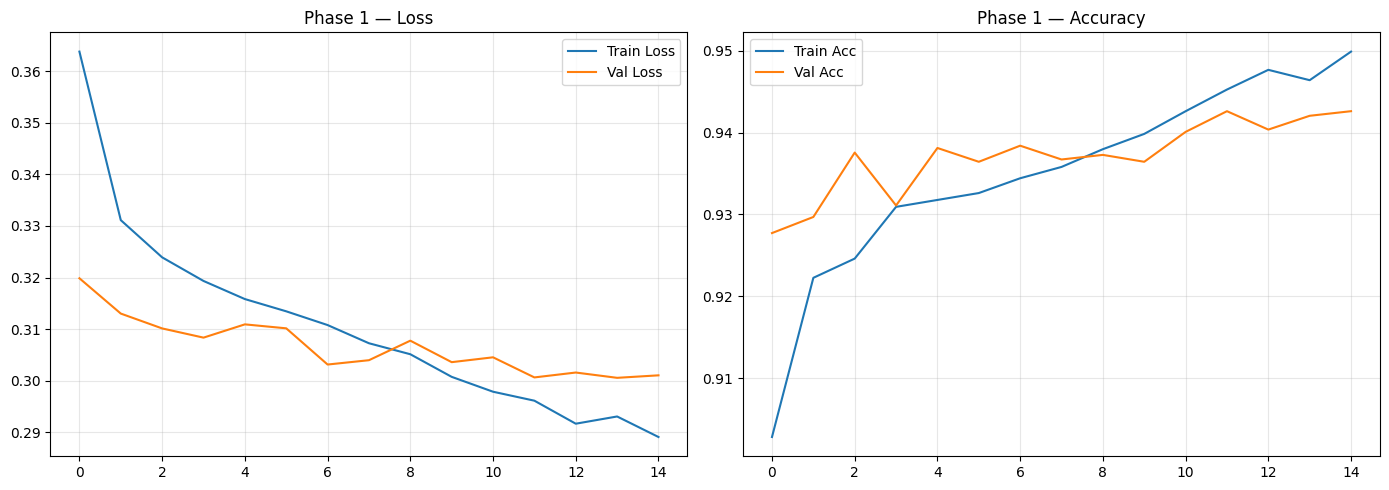

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(p1_history['train_loss'], label='Train Loss')
axes[0].plot(p1_history['val_loss'], label='Val Loss')
axes[0].set_title('Phase 1 — Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(p1_history['train_acc'], label='Train Acc')
axes[1].plot(p1_history['val_acc'], label='Val Acc')
axes[1].set_title('Phase 1 — Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

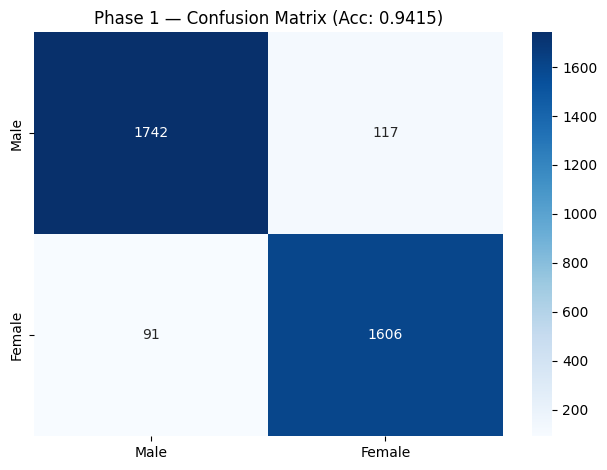

              precision    recall  f1-score   support

        male       0.95      0.94      0.94      1859
      female       0.93      0.95      0.94      1697

    accuracy                           0.94      3556
   macro avg       0.94      0.94      0.94      3556
weighted avg       0.94      0.94      0.94      3556



In [18]:
cm = confusion_matrix(p1_true, p1_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male','Female'], yticklabels=['Male','Female'])
plt.title(f'Phase 1 — Confusion Matrix (Acc: {p1_acc:.4f})')
plt.tight_layout(); plt.show()

print(classification_report(p1_true, p1_pred, target_names=['male','female']))

### Phase 1 — Save Checkpoint

In [19]:
Path("models/weights").mkdir(parents=True, exist_ok=True)

p1_ckpt = {
    'model_state_dict': p1_best_state,
    'optimizer_state_dict': p1_best_opt_state,
    'history': p1_history,
    'test_accuracy': p1_acc,
    'test_loss': p1_loss,
    'best_val_loss': best_val_loss,
    'config': {
        'phase': 1,
        'backbone': GenderClassifier.BACKBONE_NAME,
        'head_dim': GenderClassifier.HIDDEN_DIM,
        'dropout': GenderClassifier.DROPOUT,
        'lr': P1_LR,
        'label_map': {0: 'male', 1: 'female'},
    },
}
torch.save(p1_ckpt, "models/weights/vit_b16_gender_phase1.pth")
print("Saved: models/weights/vit_b16_gender_phase1.pth")

Saved: models/weights/vit_b16_gender_phase1.pth


---
# Phase 2 — Unfreeze Last 4 ViT Blocks

Load Phase 1 best weights, unfreeze last 4 transformer blocks, train with discriminative LR.

In [20]:
# Reset model
model = GenderClassifier()
model.freeze_backbone()
model.load_state_dict(p1_best_state)

# Unfreeze last 4 blocks
N_UNFREEZE = 4
model.unfreeze_last_n_blocks(N_UNFREEZE)
model = model.to(DEVICE)

print(f"Total params:     {model.num_total:,}")
print(f"Trainable params: {model.num_trainable:,} ({100*model.num_trainable/model.num_total:.2f}%)")
print(f"Unfrozen blocks:  last {N_UNFREEZE} ViT blocks + norm")

Total params:     85,997,570
Trainable params: 28,551,938 (33.20%)
Unfrozen blocks:  last 4 ViT blocks + norm


### Phase 2 — Hyperparameters (Discriminative LR)

In [21]:
P2_EPOCHS = 15
P2_LR_BACKBONE = 1e-5
P2_LR_HEAD = 1e-4
P2_WD = 1e-4
P2_PATIENCE = 5
P2_DELTA = 0.001

# Separate backbone params from head params for discriminative LR
bb_params, head_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if name.startswith('head'):
        head_params.append(p)
    else:
        bb_params.append(p)

optimizer_p2 = optim.AdamW([
    {'params': bb_params, 'lr': P2_LR_BACKBONE},
    {'params': head_params, 'lr': P2_LR_HEAD},
], weight_decay=P2_WD)

scheduler_p2 = CosineAnnealingLR(optimizer_p2, T_max=P2_EPOCHS, eta_min=1e-7)
criterion_p2 = LabelSmoothingCrossEntropy(smoothing=0.1)

print(f"Phase 2: backbone LR={P2_LR_BACKBONE} | head LR={P2_LR_HEAD} | wd={P2_WD}")
print(f"  Unfrozen backbone params: {sum(p.numel() for p in bb_params):,}")
print(f"  Head params:              {sum(p.numel() for p in head_params):,}")

Phase 2: backbone LR=1e-05 | head LR=0.0001 | wd=0.0001
  Unfrozen backbone params: 28,353,024
  Head params:              198,914


### Phase 2 — Training Loop

In [22]:
best_val_loss_p2 = float('inf')
best_val_acc_p2 = 0.0
stale_epochs_p2 = 0
p2_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8} |"
      f"{'LR BB':>8} |{'LR Hd':>7} | Early")
print("-" * 85)

for epoch in range(1, P2_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion_p2, optimizer_p2, DEVICE)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, criterion_p2, DEVICE)
    lr_bb = optimizer_p2.param_groups[0]['lr']
    lr_hd = optimizer_p2.param_groups[1]['lr']
    scheduler_p2.step()

    p2_history['train_loss'].append(tr_loss)
    p2_history['train_acc'].append(tr_acc)
    p2_history['val_loss'].append(vl_loss)
    p2_history['val_acc'].append(vl_acc)

    status = ''
    if vl_loss < best_val_loss_p2 - P2_DELTA:
        best_val_loss_p2 = vl_loss
        best_val_acc_p2 = vl_acc
        p2_best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        stale_epochs_p2 = 0
        status = 'saved'
    else:
        stale_epochs_p2 += 1
        status = f'pat {stale_epochs_p2}/{P2_PATIENCE}'

    print(f"{epoch:>6} | {tr_loss:>10.6f} | {tr_acc:>9.4f} | {vl_loss:>9.6f} | {vl_acc:>8.4f} |"
          f"{lr_bb:>1.2e} |{lr_hd:>1.2e} | {status}")

    if stale_epochs_p2 >= P2_PATIENCE:
        print(f"Phase 2 early stopping @ epoch {epoch}")
        break

model.load_state_dict(p2_best_state)
print(f"\nPhase 2 done. Best val loss: {best_val_loss_p2:.6f}, acc: {best_val_acc_p2:.4f}")

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |   LR BB |  LR Hd | Early
-------------------------------------------------------------------------------------


Train:   0%|          | 0/260 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

     1 |   0.295962 |    0.9441 |  0.304300 |   0.9390 |1.00e-05 |1.00e-04 | saved


Train:   0%|          | 0/260 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

     8 |   0.254930 |    0.9697 |  0.293291 |   0.9469 |5.57e-06 |5.53e-05 | pat 4/5


Train:   0%|          | 0/260 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

     9 |   0.250914 |    0.9729 |  0.295038 |   0.9466 |4.53e-06 |4.48e-05 | pat 5/5
Phase 2 early stopping @ epoch 9

Phase 2 done. Best val loss: 0.292961, acc: 0.9463


### Phase 2 — Test Set Evaluation

In [23]:
p2_loss, p2_acc, p2_true, p2_pred, p2_probs = eval_epoch(model, test_loader, criterion_p2, DEVICE)
print(f"Phase 2 Test — Loss: {p2_loss:.6f} | Acc: {p2_acc:.4f} | AUC: {roc_auc_score(p2_true, p2_probs[:,1]):.4f}")

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

Phase 2 Test — Loss: 0.299875 | Acc: 0.9443 | AUC: 0.9797


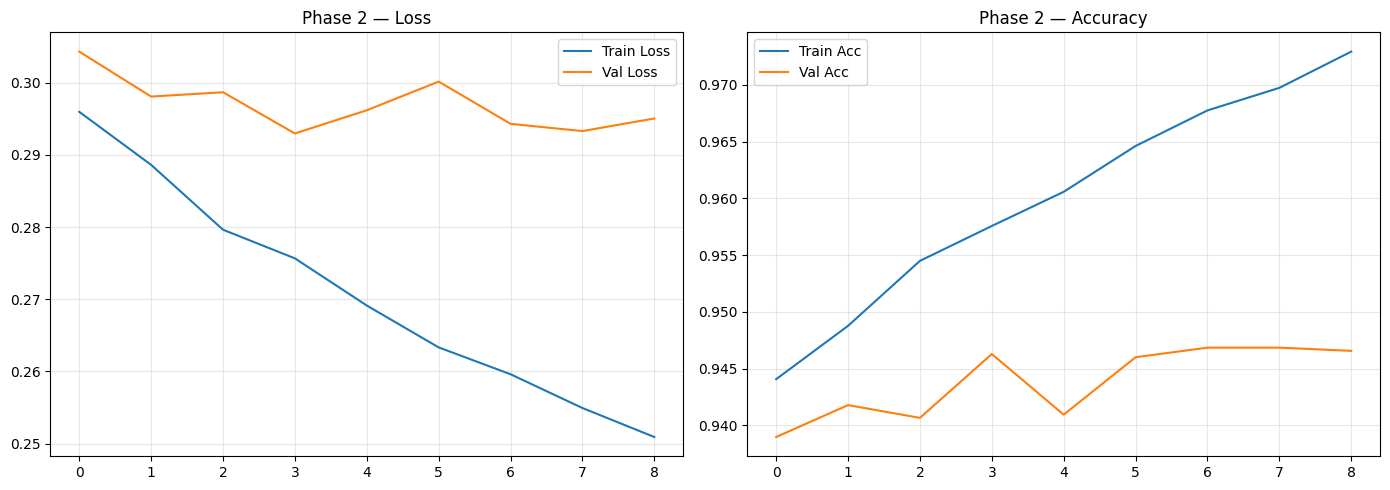

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(p2_history['train_loss'], label='Train Loss')
axes[0].plot(p2_history['val_loss'], label='Val Loss')
axes[0].set_title('Phase 2 — Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(p2_history['train_acc'], label='Train Acc')
axes[1].plot(p2_history['val_acc'], label='Val Acc')
axes[1].set_title('Phase 2 — Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

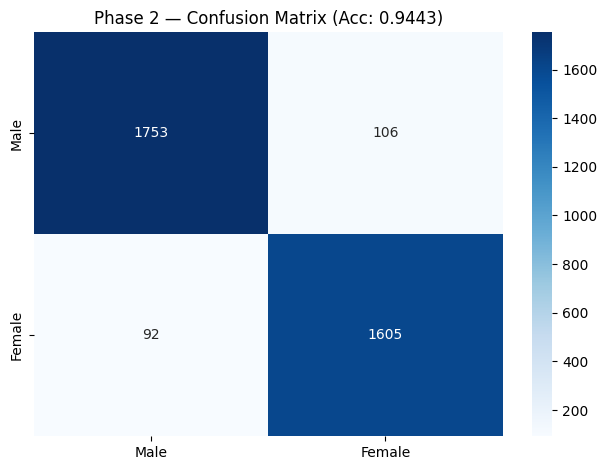

              precision    recall  f1-score   support

        male       0.95      0.94      0.95      1859
      female       0.94      0.95      0.94      1697

    accuracy                           0.94      3556
   macro avg       0.94      0.94      0.94      3556
weighted avg       0.94      0.94      0.94      3556



In [25]:
cm = confusion_matrix(p2_true, p2_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male','Female'], yticklabels=['Male','Female'])
plt.title(f'Phase 2 — Confusion Matrix (Acc: {p2_acc:.4f})')
plt.tight_layout(); plt.show()

print(classification_report(p2_true, p2_pred, target_names=['male','female']))

## Phase Comparison

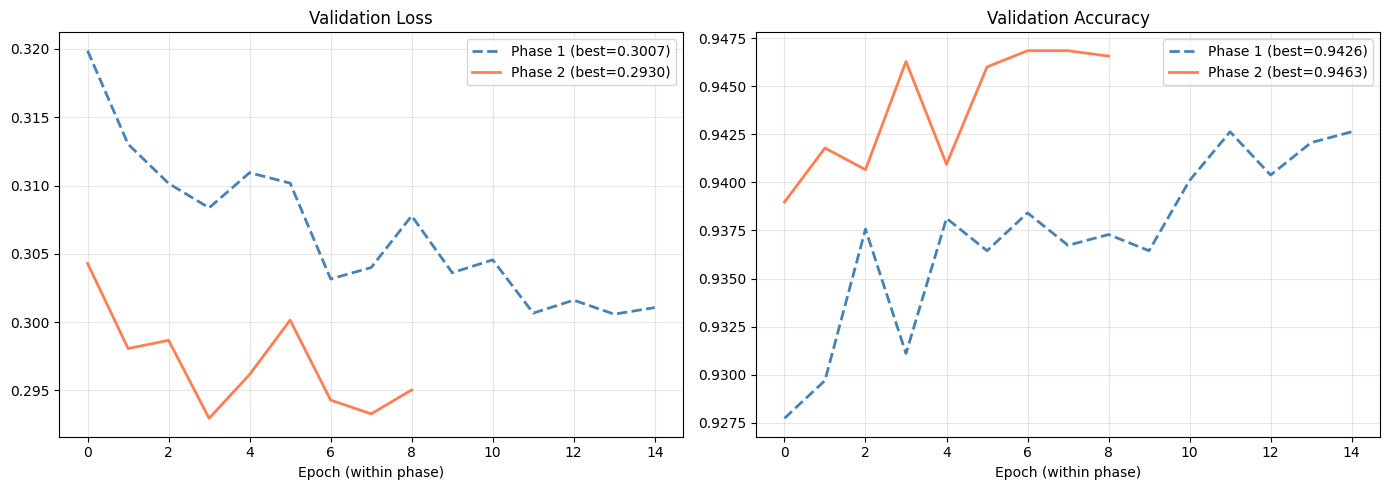

Metric               |    Phase 1 |    Phase 2
---------------------------------------------
Test Accuracy        |     0.9415 |     0.9443
Test Loss            |   0.302940 |   0.299875
Improvement          |            |    +0.0028


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p1_history['val_loss'], '--', label=f"Phase 1 (best={best_val_loss:.4f})",
             linewidth=2, color='steelblue')
axes[0].plot(p2_history['val_loss'], '-', label=f"Phase 2 (best={best_val_loss_p2:.4f})",
             linewidth=2, color='coral')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch (within phase)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(p1_history['val_acc'], '--', label=f"Phase 1 (best={best_val_acc:.4f})",
             linewidth=2, color='steelblue')
axes[1].plot(p2_history['val_acc'], '-', label=f"Phase 2 (best={best_val_acc_p2:.4f})",
             linewidth=2, color='coral')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch (within phase)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("=" * 45)
print(f"{'Metric':<20} | {'Phase 1':>10} | {'Phase 2':>10}")
print("-" * 45)
print(f"{'Test Accuracy':<20} | {p1_acc:>10.4f} | {p2_acc:>10.4f}")
print(f"{'Test Loss':<20} | {p1_loss:>10.6f} | {p2_loss:>10.6f}")
print(f"{'Improvement':<20} | {'':>10} | {p2_acc - p1_acc:>+10.4f}")
print("=" * 45)

## Save Phase 2 Weights

In [27]:
p2_ckpt = {
    'model_state_dict': p2_best_state,
    'history': p2_history,
    'phase1_history': p1_history,
    'test_accuracy': p2_acc,
    'test_loss': p2_loss,
    'best_val_loss': best_val_loss_p2,
    'best_val_acc': best_val_acc_p2,
    'config': {
        'phase': 2,
        'backbone': GenderClassifier.BACKBONE_NAME,
        'head_dim': GenderClassifier.HIDDEN_DIM,
        'dropout': GenderClassifier.DROPOUT,
        'unfrozen_blocks': N_UNFREEZE,
        'lr_backbone': P2_LR_BACKBONE,
        'lr_head': P2_LR_HEAD,
        'label_map': {0: 'male', 1: 'female'},
    },
}
torch.save(p2_ckpt, "models/weights/vit_b16_gender_phase2.pth")
print("Saved: models/weights/vit_b16_gender_phase2.pth")

Saved: models/weights/vit_b16_gender_phase2.pth


In [28]:
from google.colab import files
print("Download Phase 1 weights...")
files.download("models/weights/vit_b16_gender_phase1.pth")
print("Download Phase 2 weights...")
files.download("models/weights/vit_b16_gender_phase2.pth")

Download Phase 1 weights...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download Phase 2 weights...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
**Next Steps:**
1. Download both `.pth` files via the Colab file dialog (triggered above)
2. Place them in your local `models/weights/` folder
3. Update `configs/config.yaml` to point to `vit_b16_gender_phase2.pth`
4. Run the production `GenderDetectionComponent`